In [11]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torch.nn.functional as F
import psutil
import logging

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()


In [12]:
logging.basicConfig(
    filename="memory_log.txt",
    level=logging.INFO,
    format="%(asctime)s %(message)s"
)

def log_memory(tag=""):
    process = psutil.Process(os.getpid())
    cpu_mem = process.memory_info().rss / 1024**3

    if torch.cuda.is_available():
        gpu_alloc = torch.cuda.memory_allocated() / 1024**3
        gpu_reserved = torch.cuda.memory_reserved() / 1024**3
    else:
        gpu_alloc = gpu_reserved = 0

    logging.info(
        f"{tag} | CPU {cpu_mem:.3f} GB | GPU alloc {gpu_alloc:.3f} GB | GPU reserved {gpu_reserved:.3f} GB"
    )

In [13]:
if not os.path.exists('tiny_nerf_data.npz'):
    !wget http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz

(106, 100, 100, 3) (106, 4, 4) 138.88887889922103


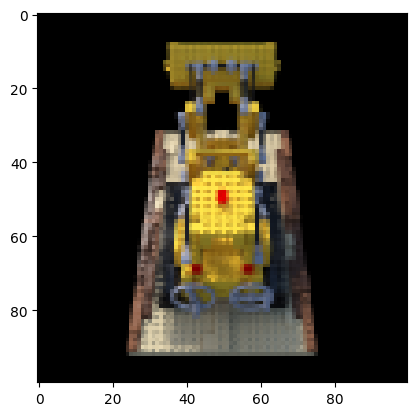

In [14]:
data = np.load('tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal = data['focal']
H, W = images.shape[1:3]
print(images.shape, poses.shape, focal)

testimg, testpose = images[102], poses[102]
images = images[:100,...,:3]
poses = poses[:100]

images = torch.from_numpy(images).float()
# images = torch.tensor(images, dtype=torch.float32)
poses = torch.from_numpy(poses).float()
testimg = torch.from_numpy(testimg).float()
testpose = torch.from_numpy(testpose).float()
focal = torch.from_numpy(focal).float()

plt.imshow(testimg)
plt.show()

In [15]:
# def posenc(x):
#     rets = [x]
#     for i in range(L_embed):
#         for fn in [torch.sin, torch.cos]:
#             rets.append(fn(2.**i * x))
#     return torch.cat(rets, dim=-1)

def posenc(x):
    freqs = 2. ** torch.arange(L_embed, device=x.device)
    xb = x[..., None] * freqs
    xb = xb.reshape(*x.shape[:-1], -1)
    return torch.cat([x, torch.sin(xb), torch.cos(xb)], dim=-1)

L_embed = 6
embed_fn = posenc

In [16]:
class NeRF(nn.Module):
    def __init__(self, D=8, W=256, input_dim= 3 + 3 * 2 * L_embed , output_dim=4):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, W))
        for i in range(1, D):
            if i % 4 == 0 and i > 0:
                self.layers.append(nn.Linear(W + input_dim, W))
            else:
                self.layers.append(nn.Linear(W, W))
        self.output_layer = nn.Linear(W, output_dim)

    def forward(self, x):
        input_x = x
        for i, layer in enumerate(self.layers):
            if i % 4 == 0 and i > 0:
                x = torch.cat([x, input_x], dim=-1)
            x = layer(x)
            x = torch.relu(x)
        out = self.output_layer(x)
        return out

In [17]:
def get_rays(H, W, focal, c2w):
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32, device=c2w.device), torch.arange(H, dtype=torch.float32, device=c2w.device), indexing='xy')
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], -1)
    rays_d = torch.sum(dirs[..., np.newaxis, :] * c2w[:3,:3], -1)  # dot product, equals to: [c2w.dot(dir) for dir in dirs]
    rays_o = c2w[:3,-1].expand(rays_d.shape)
    return rays_o, rays_d



def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, rand=False):

    def batchify(fn, chunk=64*32):
        return lambda inputs: torch.cat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], dim=0)

    # Compute 3D query points
    z_vals = torch.linspace(near, far, N_samples, device=rays_o.device)  # (N_samples,)
    if rand:
        z_vals = z_vals + torch.rand( list(rays_o.shape[:-1]) + [N_samples], device=rays_o.device) * (far - near) / N_samples
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]

    # Run network
    pts_flat = pts.reshape(-1, 3)
    pts_flat = embed_fn(pts_flat)
    raw = batchify(network_fn)(pts_flat)
    raw = raw.reshape(list(pts.shape[:-1]) + [4])

    # Compute opacities and colors
    sigma_a = F.relu(raw[..., 3])
    rgb = torch.sigmoid(raw[..., :3])

    # Volume rendering
    dists = torch.cat([z_vals[..., 1:] - z_vals[..., :-1], torch.full_like(z_vals[..., :1], 1e10)], dim=-1)
    alpha = 1. - torch.exp(-sigma_a * dists)
    weights = alpha * torch.cumprod(torch.cat([torch.ones_like(alpha[..., :1]), 1. - alpha + 1e-10], dim=-1), dim=-1)[..., :-1]

    rgb_map   = torch.sum(weights[..., None] * rgb, dim=-2)
    depth_map = torch.sum(weights * z_vals, dim=-1)
    acc_map   = torch.sum(weights, dim=-1)

    return rgb_map, depth_map, acc_map



0 0.029861526489257814 secs per iter


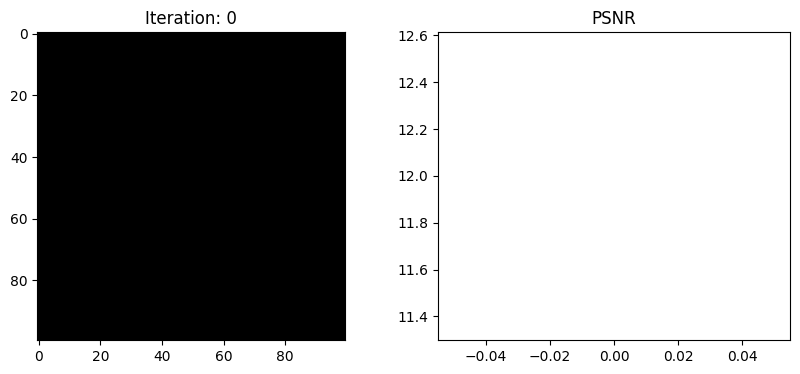

25 0.27464468002319337 secs per iter


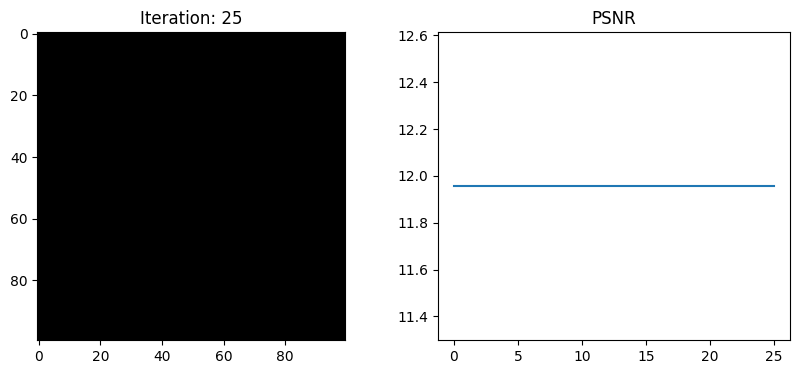

50 0.16879424095153808 secs per iter


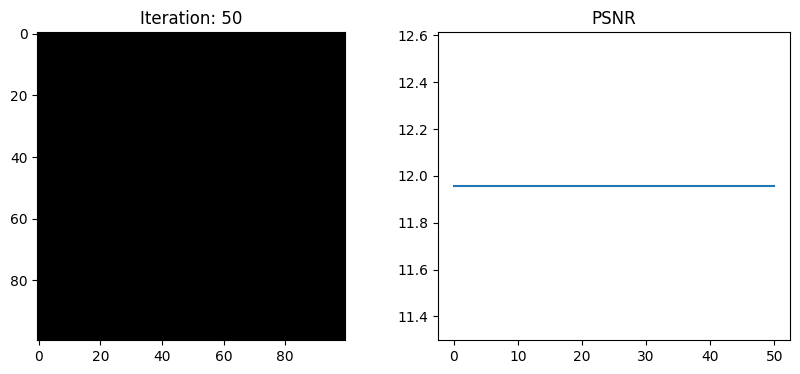

75 0.1579465675354004 secs per iter


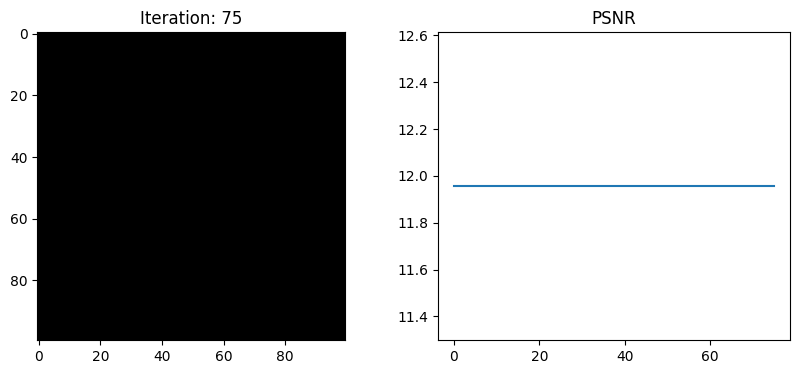

100 0.15752538681030273 secs per iter


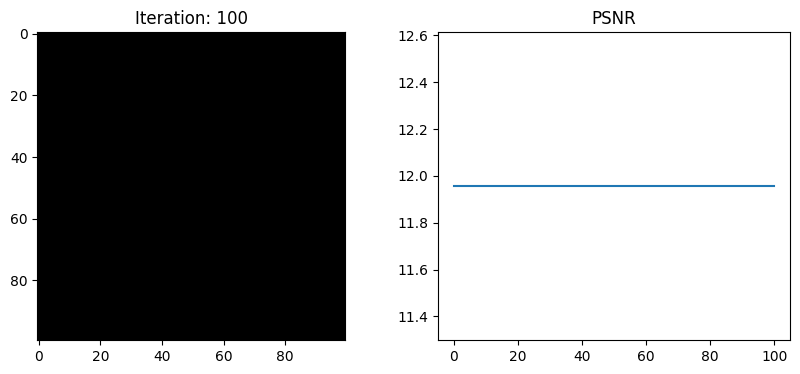

125 0.15594855308532715 secs per iter


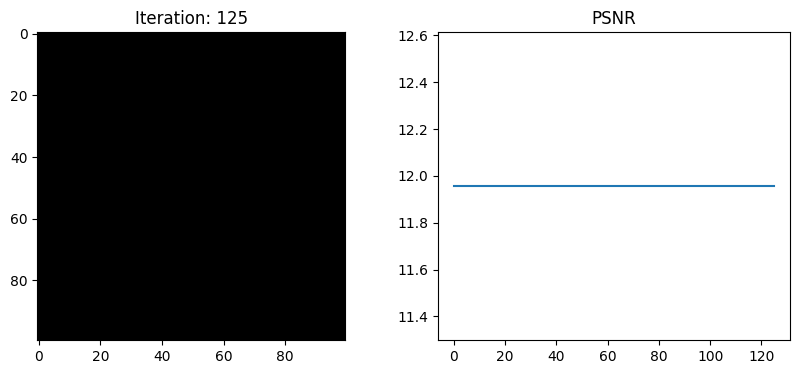

150 0.15892492294311522 secs per iter


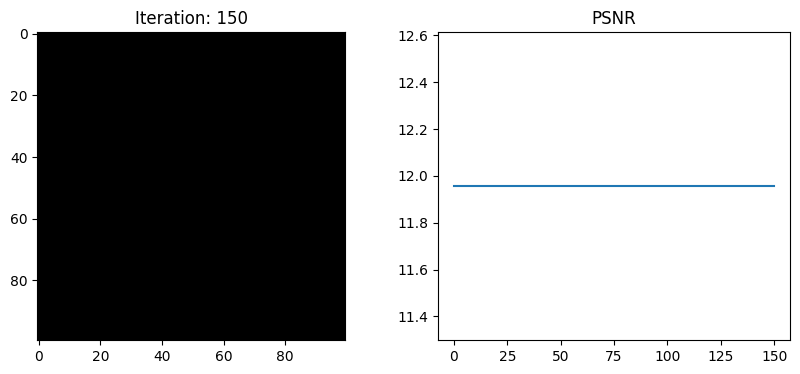

175 0.16023934364318848 secs per iter


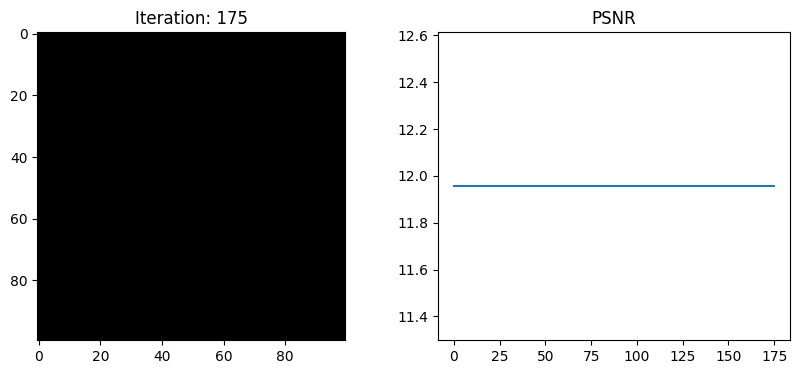

200 0.1572972583770752 secs per iter


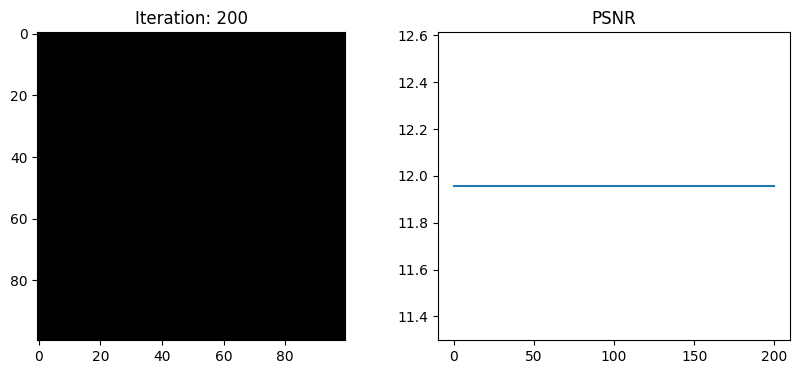

225 0.15944631576538085 secs per iter


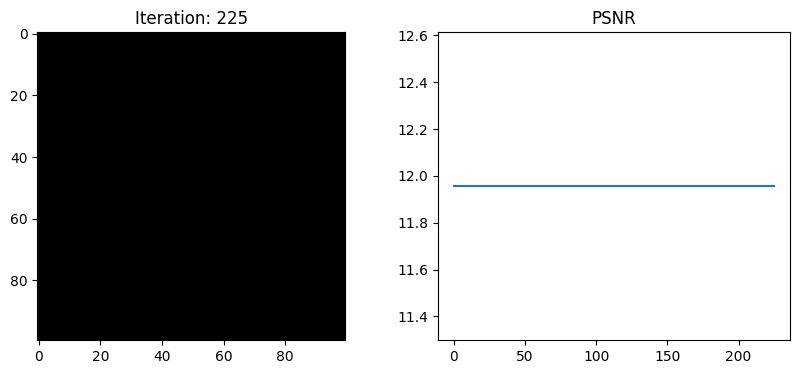

250 0.15926281929016115 secs per iter


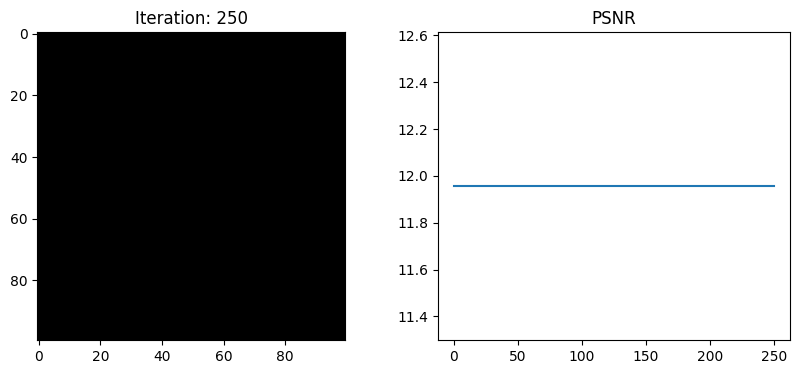

275 0.16339397430419922 secs per iter


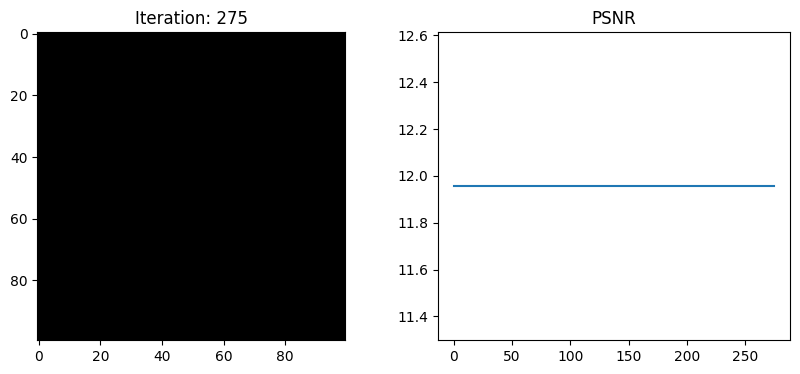

300 0.15800943374633789 secs per iter


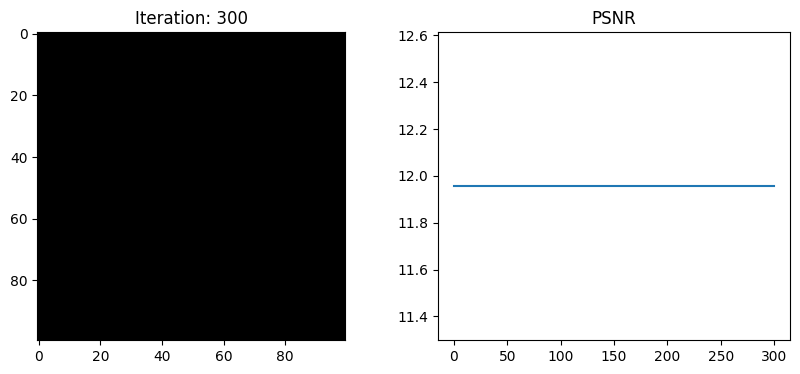

325 0.1605901050567627 secs per iter


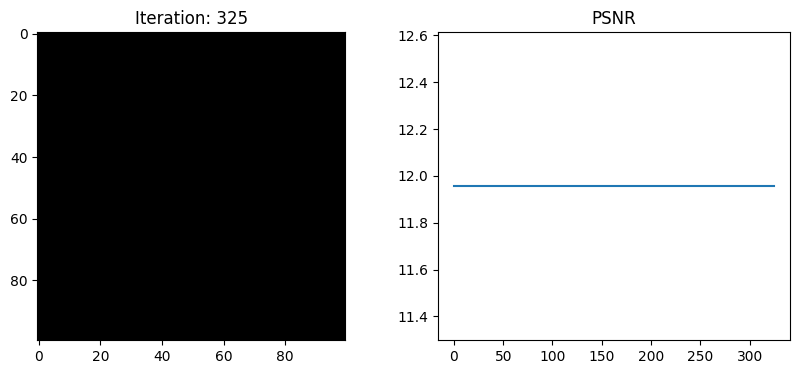

350 0.16195253372192384 secs per iter


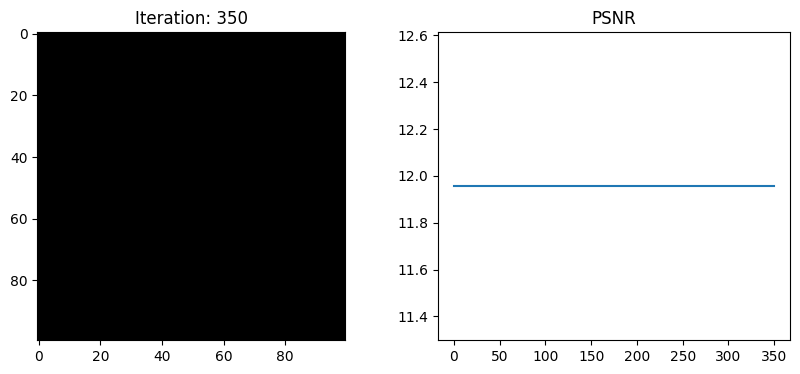

375 0.16508722305297852 secs per iter


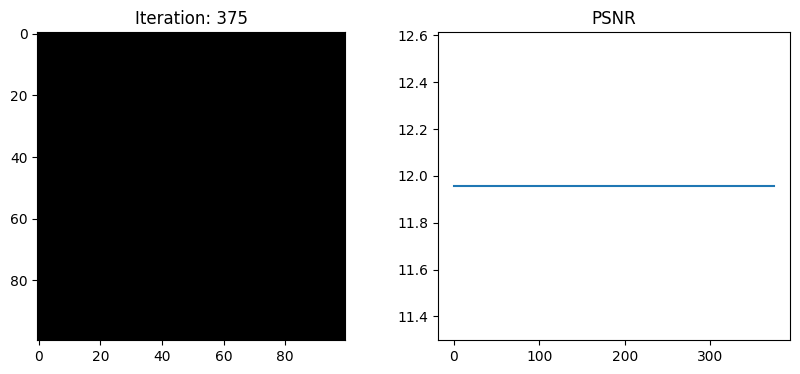

400 0.16251441955566406 secs per iter


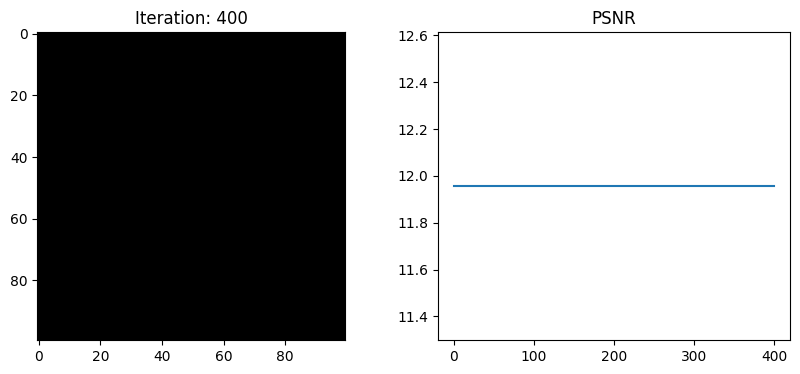

425 0.1661486053466797 secs per iter


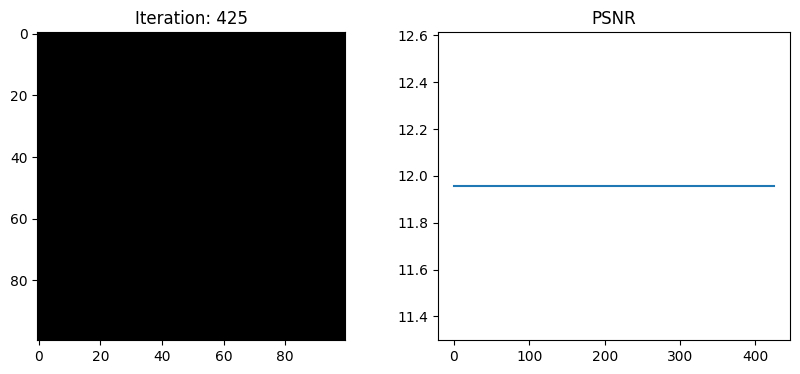

450 0.1613338088989258 secs per iter


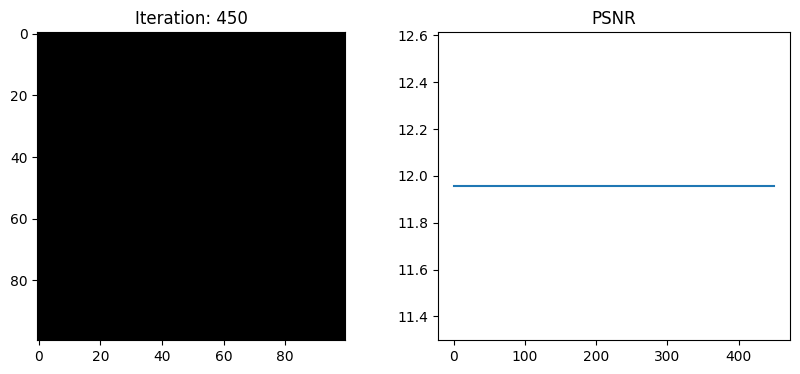

475 0.17089584350585937 secs per iter


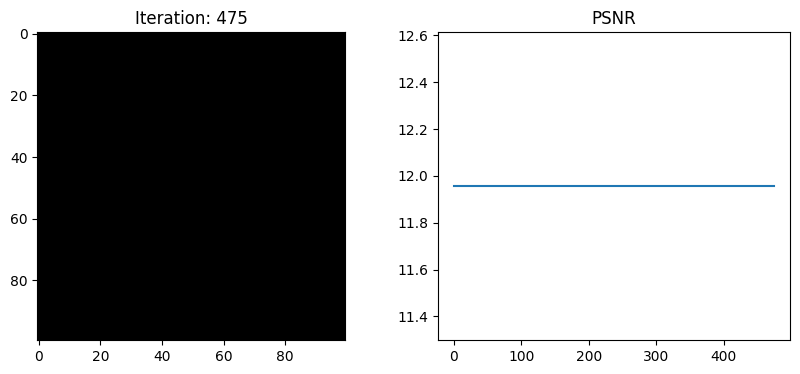

500 0.16470469474792482 secs per iter


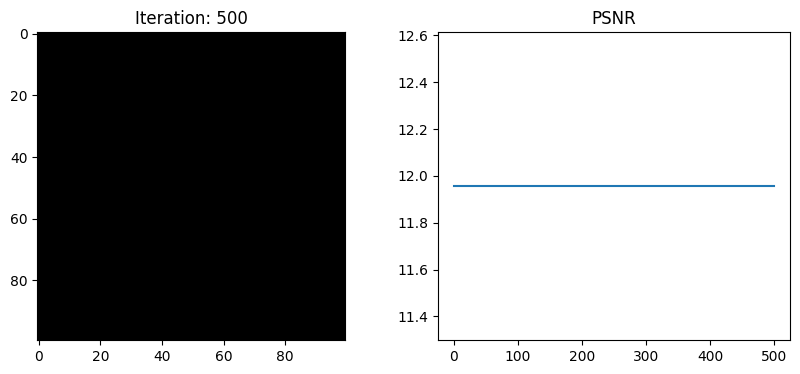

525 0.16289517402648926 secs per iter


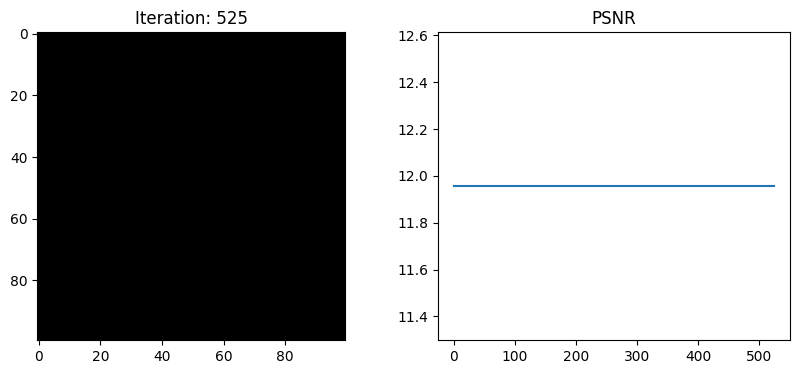

550 0.16531956672668457 secs per iter


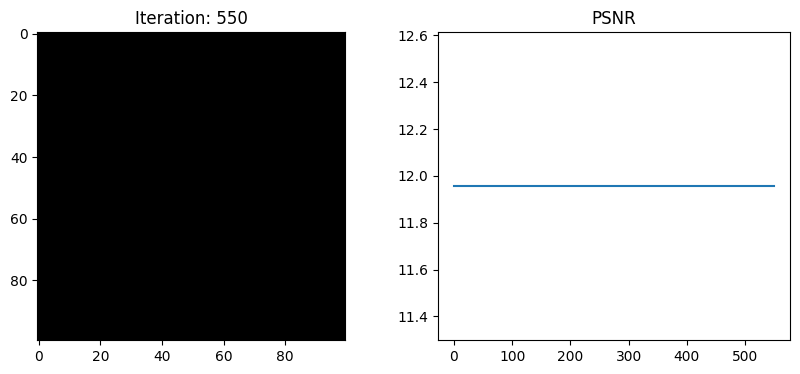

575 0.16287991523742676 secs per iter


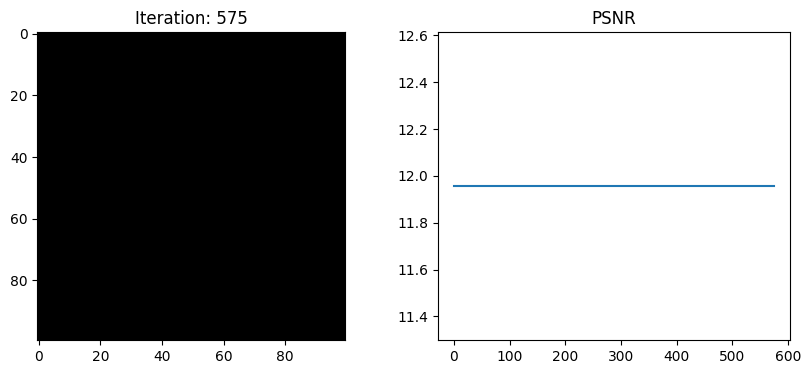

600 0.16114779472351073 secs per iter


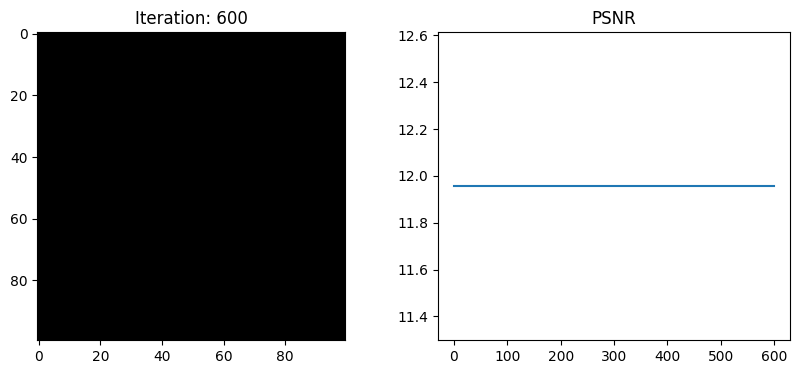

625 0.16569768905639648 secs per iter


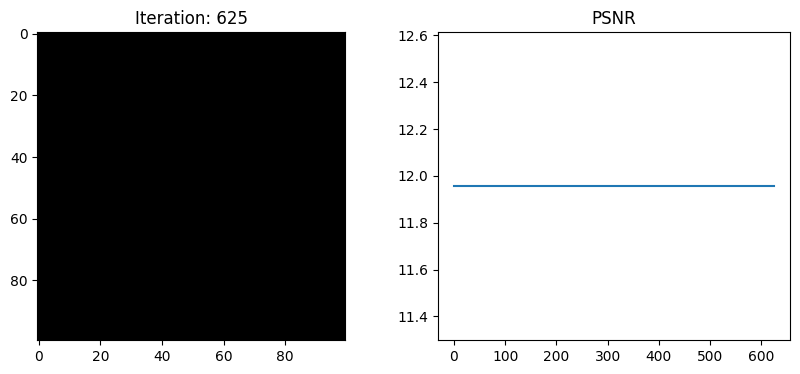

650 0.16666136741638182 secs per iter


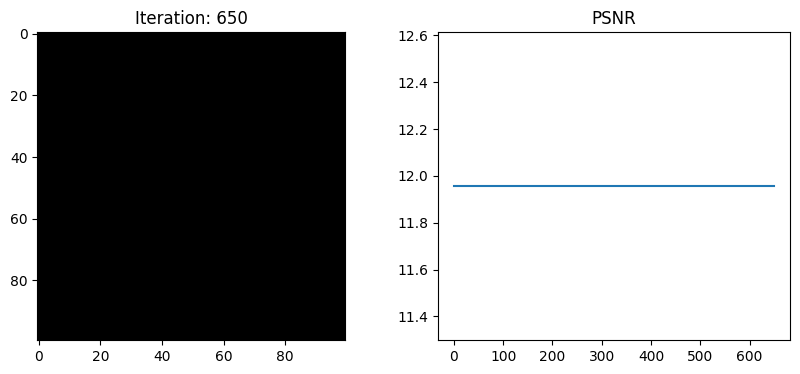

675 0.1630309009552002 secs per iter


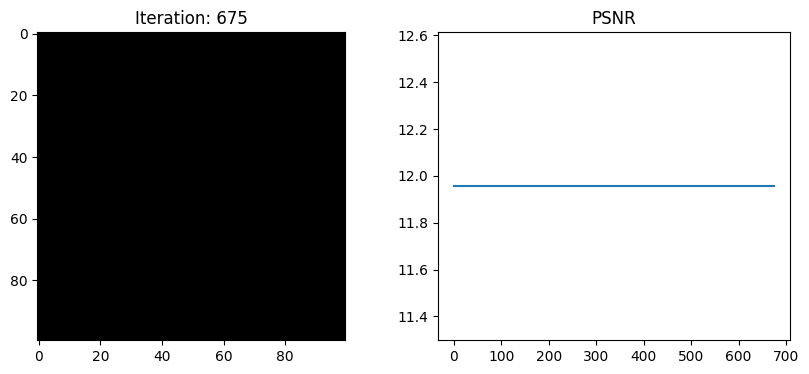

700 0.16211825370788574 secs per iter


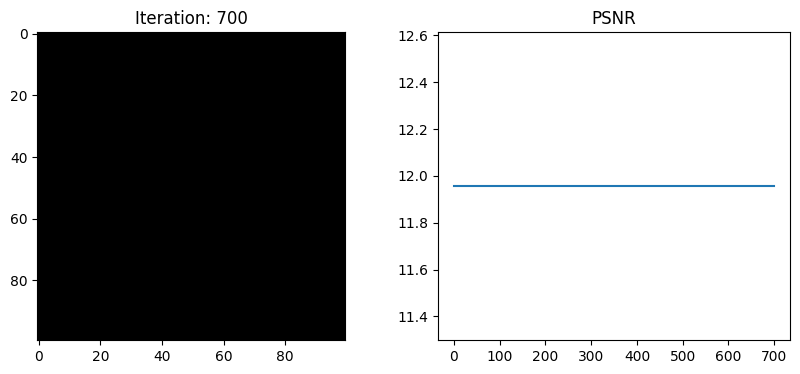

725 0.1655501079559326 secs per iter


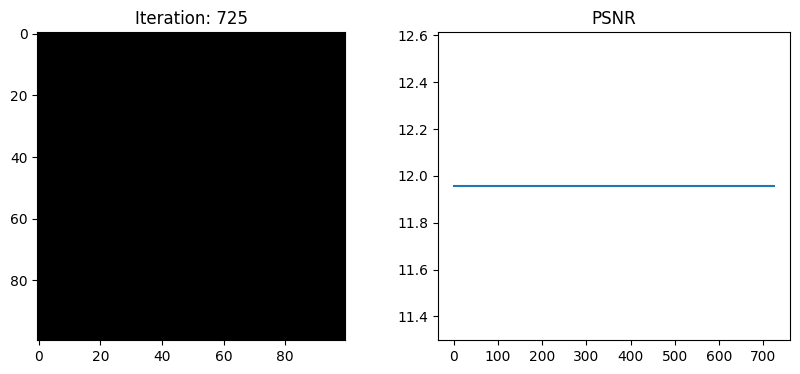

750 0.1679842948913574 secs per iter


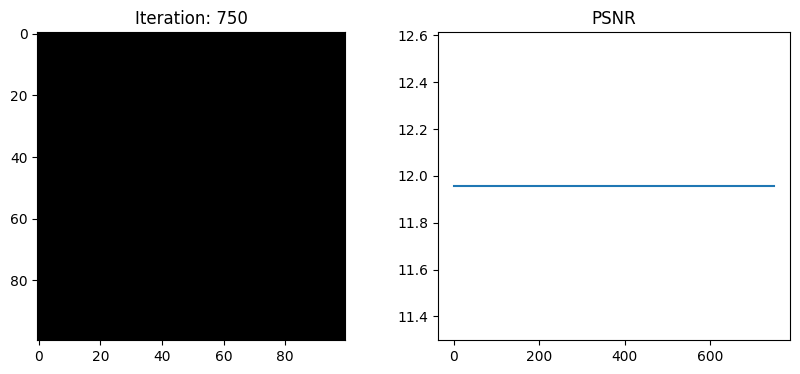

775 0.1647561740875244 secs per iter


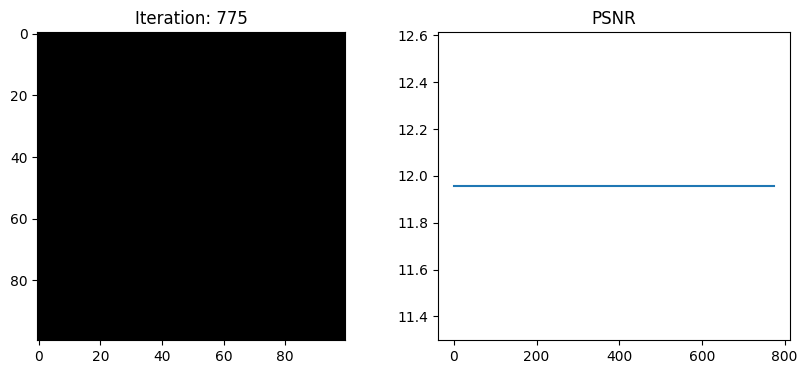

800 0.16300622940063478 secs per iter


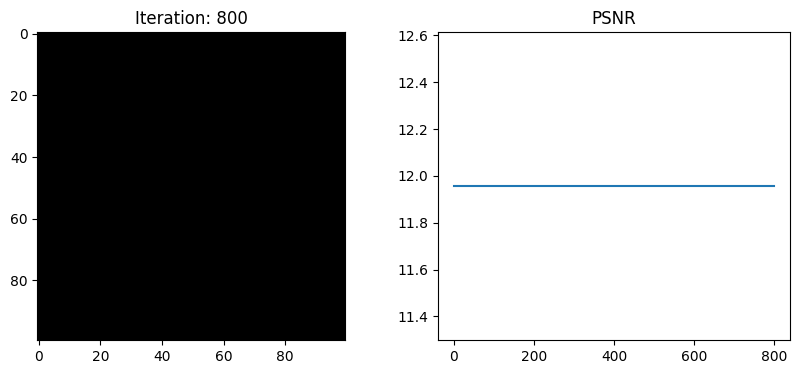

825 0.16636139869689942 secs per iter


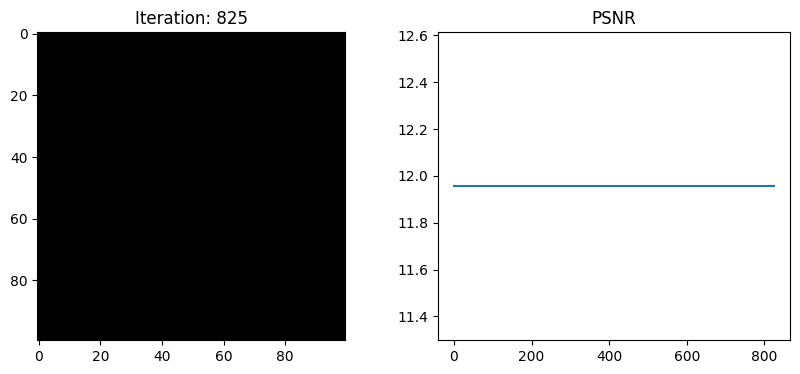

850 0.16772903442382814 secs per iter


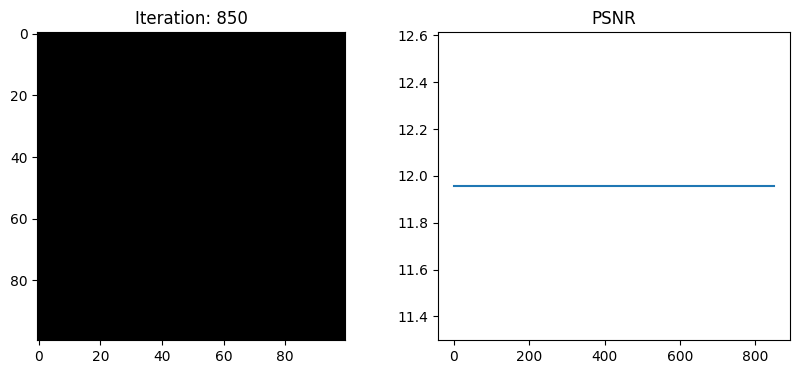

875 0.16829267501831055 secs per iter


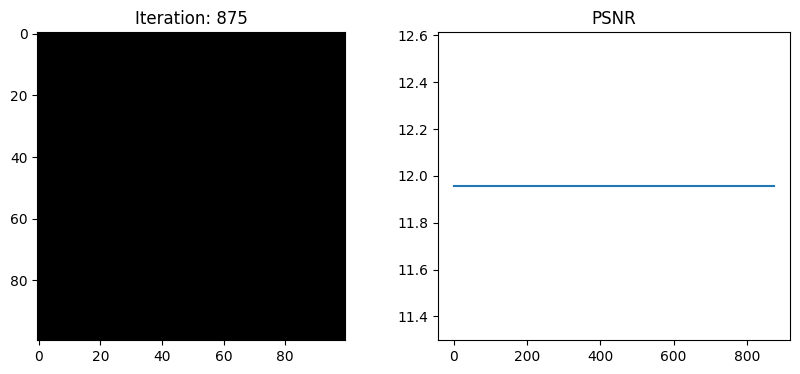

900 0.172290620803833 secs per iter


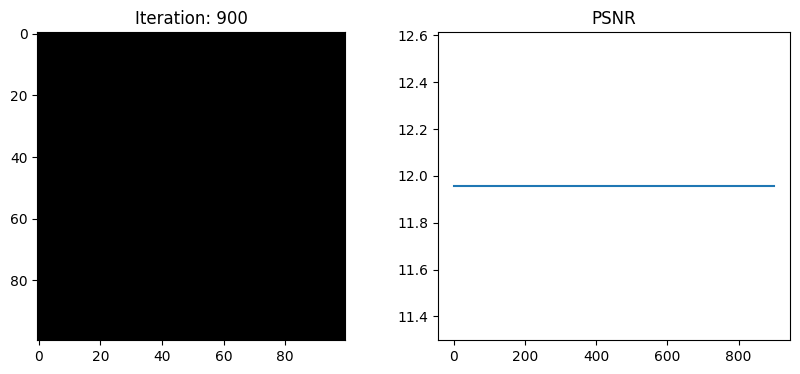

925 0.1654070472717285 secs per iter


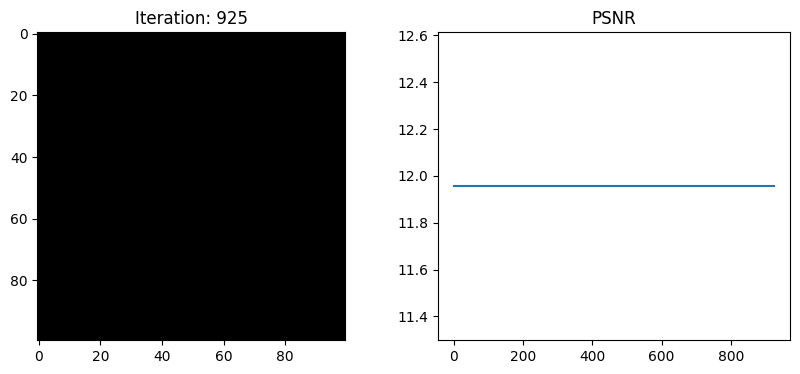

950 0.16641489982604982 secs per iter


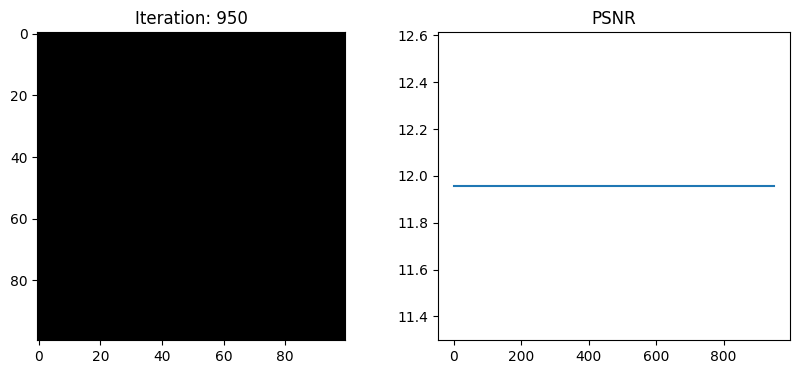

975 0.16737000465393068 secs per iter


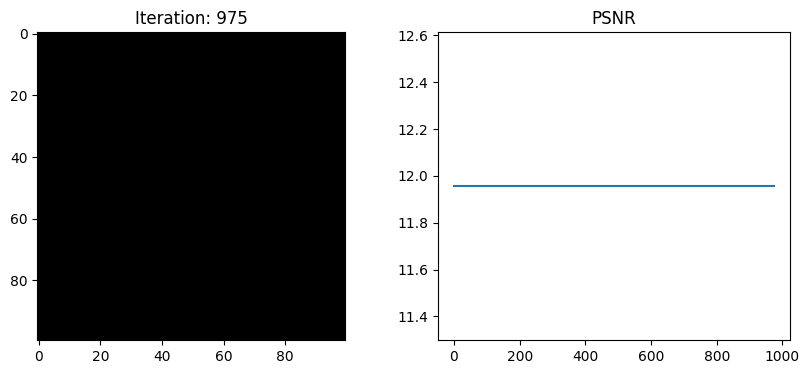

1000 0.1691230869293213 secs per iter


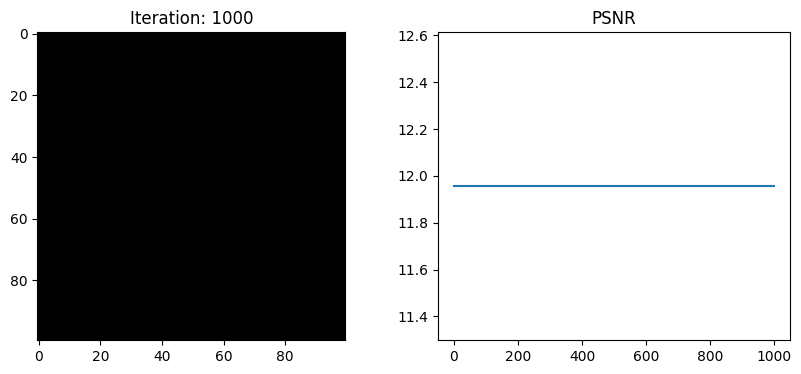

In [18]:
model = NeRF()
optimizer = optim.Adam(model.parameters(), lr=5e-4)
model.to(device)
focal = focal.to(device)

N_samples = 64 
N_iters = 1000
psnrs = []
iternums = []
i_plot = 25

def render_rays_chunked(model, rays_o, rays_d, chunk=1024):

    rgb_chunks = []

    for i in range(0, rays_o.shape[0], chunk):

        rgb, _, _ = render_rays(
            model,
            rays_o[i:i+chunk],
            rays_d[i:i+chunk],
            near=2.,
            far=6.,
            N_samples=N_samples,
            rand=True
        )

        rgb_chunks.append(rgb)

    return torch.cat(rgb_chunks, dim=0)

import time
t = time.time()
for i in range(N_iters + 1):

    log_memory("iter_start")

    img_i = np.random.randint(images.shape[0])

    target = images[img_i].to(device)
    pose = poses[img_i].to(device)

    rays_o, rays_d = get_rays(H, W, focal, pose)

    rays_o = rays_o.reshape(-1,3)
    rays_d = rays_d.reshape(-1,3)
    target = target.reshape(-1,3)

    select_inds = torch.randperm(rays_o.shape[0])[:2048]

    rays_o = rays_o[select_inds]
    rays_d = rays_d[select_inds]
    target = target[select_inds]

    rgb_pred = render_rays_chunked(model, rays_o, rays_d, chunk=1024)

    loss = torch.mean((rgb_pred - target)**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    log_memory("after_train")



    if i%i_plot==0:
        print(i, (time.time() - t) / i_plot, 'secs per iter')
        t = time.time()

        # Render the holdout view for logging
        rays_o_test, rays_d_test = get_rays(H, W, focal, testpose.to(device))
        with torch.no_grad():
            rays_o_test, rays_d_test = get_rays(H, W, focal, testpose.to(device))

            rays_o_test = rays_o_test.reshape(-1,3)
            rays_d_test = rays_d_test.reshape(-1,3)

            rgb = render_rays_chunked(model, rays_o_test, rays_d_test, chunk=1024)

            rgb = rgb.reshape(H,W,3)
            
        loss_test = torch.mean((rgb - testimg.to(device)) ** 2)
        psnr = -10 * torch.log10(loss_test).item()
        psnrs.append(psnr)
        iternums.append(i)

        plt.figure(figsize=(10,4))
        plt.subplot(121)
        plt.imshow(rgb.detach().cpu().numpy())
        plt.title(f'Iteration: {i}')
        plt.subplot(122)
        plt.plot(iternums, psnrs)
        plt.title('PSNR')
        plt.show()
    torch.cuda.empty_cache()

In [19]:
%matplotlib inline
from ipywidgets import interactive, widgets


trans_t = lambda t : torch.tensor([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,1,t],
    [0,0,0,1],
], dtype=torch.float32)

rot_phi = lambda phi : torch.tensor([
    [1,0,0,0],
    [0,torch.cos(torch.tensor(phi)),-torch.sin(torch.tensor(phi)),0],
    [0,torch.sin(torch.tensor(phi)), torch.cos(torch.tensor(phi)),0],
    [0,0,0,1],
], dtype=torch.float32)

rot_theta = lambda th : torch.tensor([
    [torch.cos(torch.tensor(th)),0,-torch.sin(torch.tensor(th)),0],
    [0,1,0,0],
    [torch.sin(torch.tensor(th)),0, torch.cos(torch.tensor(th)),0],
    [0,0,0,1],
], dtype=torch.float32)


def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(phi/180.*np.pi) @ c2w
    c2w = rot_theta(theta/180.*np.pi) @ c2w
    # Convert the numpy array to a torch tensor before multiplication
    c2w = torch.tensor([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]], dtype=torch.float32) @ c2w
    return c2w


def f(**kwargs):
    c2w = pose_spherical(**kwargs)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    img = np.clip(rgb,0,1)

    plt.figure(2, figsize=(20,6))
    plt.imshow(img)
    plt.show()


sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(f, **{s[0] : sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

In [137]:
frames = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., 4.)
    c2w = c2w.to(device) # Move c2w to the correct device
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    frames.append((255*np.clip(rgb.detach().cpu().numpy(),0,1)).astype(np.uint8)) # Detach and move to CPU before numpy conversion

import imageio
f = 'video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

100%|██████████| 120/120 [00:21<00:00,  5.57it/s]


In [138]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)